In [31]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

train = pd.read_parquet('/content/drive/MyDrive/AI4Alzheimers/data/train.parquet')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Baseline Model

A pretrained ResNet18 model is used as a simple baseline.  
All pretrained layers are frozen, and only the final classification layer is trained.
The goal is not high accuracy, but to verify that the learning pipeline functions correctly.

In [32]:
import torch
import torch.nn as nn
from torchvision import models

# Load pretrained ResNet18
model = models.resnet18(pretrained=True)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Replace final layer for 4 classes
model.fc = nn.Linear(model.fc.in_features, 4)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [34]:
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [35]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

In [36]:
train_losses = []
val_losses = []

In [37]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import io
import torchvision.transforms as T

class MRIDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Decode JPEG bytes
        image_bytes = row['image']['bytes']
        image = Image.open(io.BytesIO(image_bytes)).convert('RGB')

        if self.transform:
            image = self.transform(image)

        label = row['label']
        return image, label

In [47]:
transform = T.Compose([
    T.Resize((224, 224)),   # was 224
    T.ToTensor()
])

train_small = train.sample(n=200, random_state=42)
val_small   = train.sample(n=50, random_state=42)

train_dataset = MRIDataset(train_small, transform=transform)
val_dataset   = MRIDataset(val_small, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=4, shuffle=False)

In [50]:
num_epochs = 3

for epoch in range(num_epochs):

    # ---- Training ----
    model.train()
    train_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # ---- Validation ----
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")


Epoch 1: Train Loss = 1.1786, Val Loss = 1.1972
Epoch 2: Train Loss = 1.1602, Val Loss = 1.2160
Epoch 3: Train Loss = 1.1798, Val Loss = 1.1962


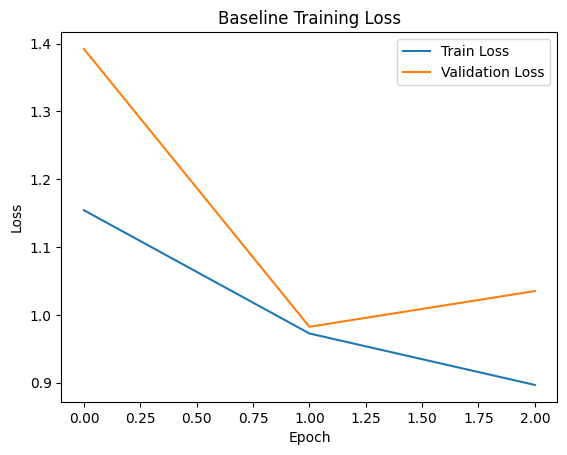

In [40]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Baseline Training Loss')
plt.legend()
plt.show()

In [51]:
torch.save(model.state_dict(), "resnet18_baseline.pt")

### Baseline Model

This baseline establishes a reference point for comparison with deeper models.
The objective is not to achieve high accuracy, but to verify that the training and validation pipeline functions correctly.

#Comparison

## MobileNet Baseline

A lightweight MobileNet model with frozen weights is used as an additional baseline
to compare against ResNet18. This helps evaluate the impact of model complexity.

In [41]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mobilenet = models.mobilenet_v2(pretrained=True)

# Freeze all layers
for param in mobilenet.parameters():
    param.requires_grad = False

# Replace classifier for 4 classes
mobilenet.classifier[1] = nn.Linear(mobilenet.last_channel, 4)

mobilenet = mobilenet.to(device)

In [42]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mobilenet.classifier.parameters(), lr=1e-3)

In [43]:
mb_train_losses = []
mb_val_losses = []

In [44]:
num_epochs = 3

for epoch in range(num_epochs):

    mobilenet.train()
    train_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = mobilenet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    mb_train_losses.append(train_loss)

    mobilenet.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = mobilenet(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    mb_val_losses.append(val_loss)

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

Epoch 1: Train Loss=1.1509, Val Loss=1.1467
Epoch 2: Train Loss=0.9027, Val Loss=0.9323
Epoch 3: Train Loss=0.9530, Val Loss=0.6899


In [45]:
import os
os.makedirs("outputs", exist_ok=True)

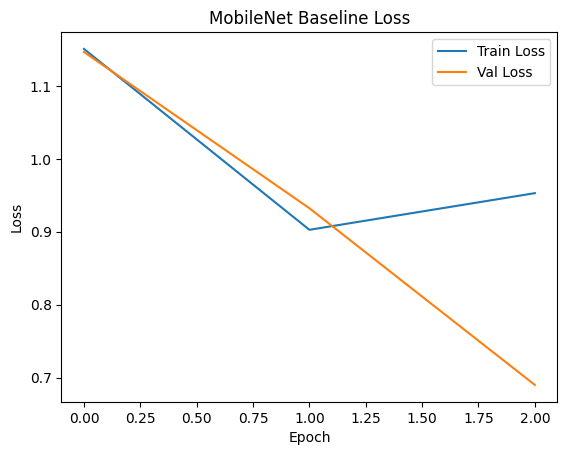

In [46]:
import matplotlib.pyplot as plt

plt.plot(mb_train_losses, label="Train Loss")
plt.plot(mb_val_losses, label="Val Loss")
plt.title("MobileNet Baseline Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("outputs/mobilenet_loss_curve.png", bbox_inches="tight")
plt.show()